In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pathlib import Path


In [3]:
data_path = Path.cwd().parent / "datasets" / "indian_liver_patient.csv"
liver_df = pd.read_csv(data_path)

### Loading And Exploring Data

In [4]:
liver_df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [5]:
liver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [6]:
# Rename target column
liver_df.rename(columns={'Dataset': 'Has_Liver_Disease'}, inplace=True)

In [7]:
# Converting target: 1=Disease, 2=No Disease → 1=Disease, 0=No Disease  
liver_df['Has_Liver_Disease'] = liver_df['Has_Liver_Disease'].map({1: 1, 2: 0})

# Map Gender: Male -> 1, Female -> 0
liver_df['Gender'] = liver_df['Gender'].map({'Female': 0, 'Male': 1})


In [8]:
print(f"Dataset shape: {liver_df.shape}")

Dataset shape: (583, 11)


In [9]:
# Checking class imbalance
print(f"\nClass Distribution:")
class_counts = liver_df['Has_Liver_Disease'].value_counts()
print(f"No Disease (0): {class_counts[0]} ({class_counts[0]/len(liver_df)*100:.1f}%)")
print(f"Disease (1): {class_counts[1]} ({class_counts[1]/len(liver_df)*100:.1f}%)")


Class Distribution:
No Disease (0): 167 (28.6%)
Disease (1): 416 (71.4%)


In [10]:
print(f"⚠️  Dataset is imbalanced! Will fix this.")

⚠️  Dataset is imbalanced! Will fix this.


### Exploratory Data Analysis


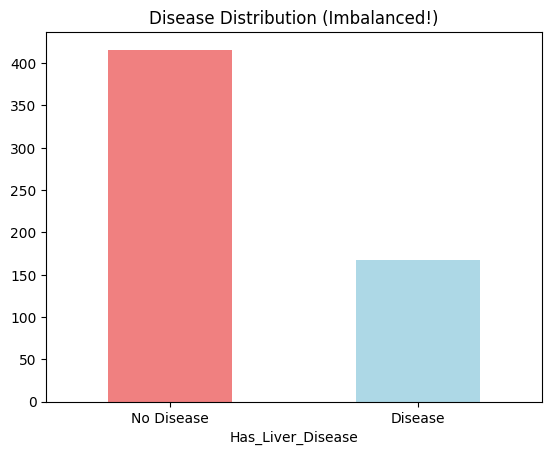

In [11]:
# Target distribution
fig, ax = plt.subplots()
class_counts.plot(kind='bar', ax=ax, color=['lightcoral', 'lightblue'])
ax.set_title('Disease Distribution (Imbalanced!)')
ax.set_xticklabels(['No Disease', 'Disease'], rotation=0)
plt.show()

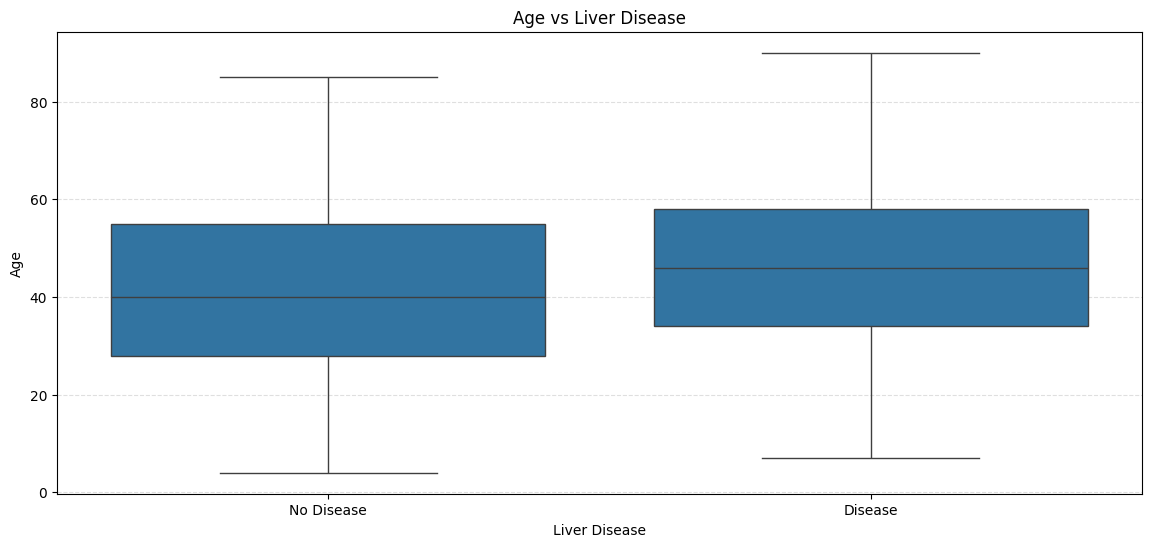

In [12]:
# Age VS Liver Disease
plt.figure(figsize=(14, 6))
sns.boxplot(data=liver_df, x='Has_Liver_Disease', y='Age')
plt.title('Age vs Liver Disease')
plt.xlabel('Liver Disease')
plt.ylabel('Age')
plt.xticks([0, 1], ['No Disease', 'Disease'])  
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()


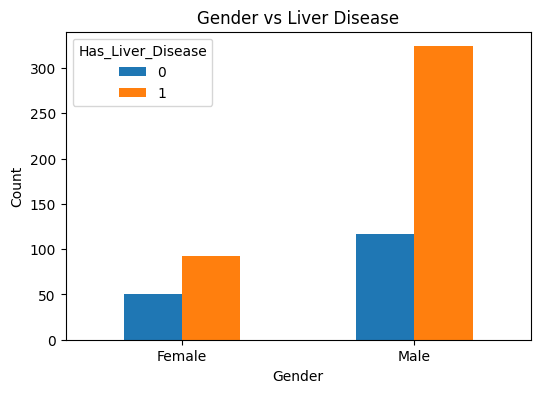

In [13]:
# Gender distribution
gender_dist = pd.crosstab(liver_df['Gender'], liver_df['Has_Liver_Disease'])
gender_dist.plot(kind='bar', figsize=(6, 4))
plt.title('Gender vs Liver Disease')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.ylabel('Count')
plt.show()


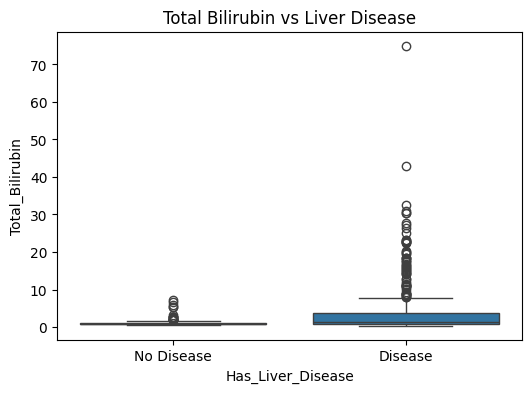

In [14]:
# Key liver enzyme
plt.figure(figsize=(6, 4))
sns.boxplot(data=liver_df, x='Has_Liver_Disease', y='Total_Bilirubin')
plt.title('Total Bilirubin vs Liver Disease')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.show()


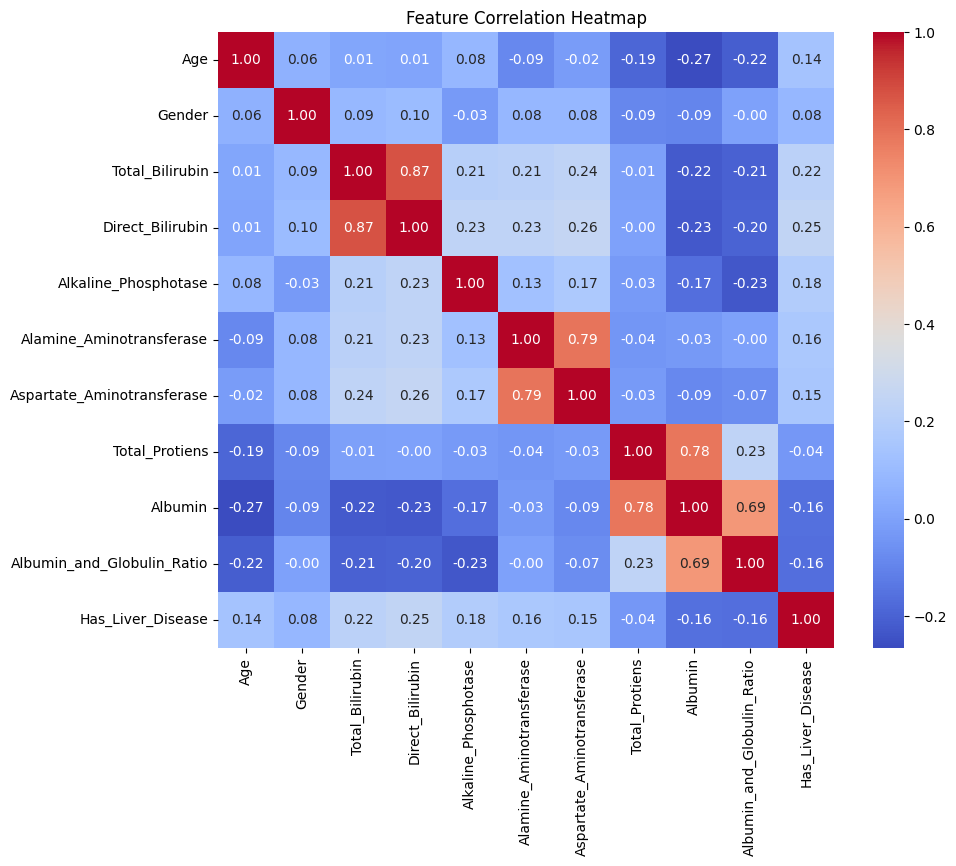

In [15]:
# Compute correlation matrix (numerical columns only)
correlation_matrix = liver_df.corr(numeric_only=True)

# Plotting correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

### PreProcessing and Data Preparation

In [16]:
X = liver_df.drop(['Has_Liver_Disease'], axis=1)  
y = liver_df['Has_Liver_Disease']

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 408
Test samples: 175


In [18]:
numerical_features = [col for col in X.columns if col != 'Gender']
categorical_features = ['Gender']

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

Numerical features: ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
Categorical features: ['Gender']


In [19]:
# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', SimpleImputer(strategy='most_frequent'), categorical_features)  
    ]
)

In [20]:
# Creating models pipeline
smote=SMOTE(random_state=42)
models = {
    'Random Forest': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', RandomForestClassifier(
            n_estimators=100, 
            random_state=42
        ))
    ]),

    'Logistic Regression': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    'Decision Tree': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', DecisionTreeClassifier(
            random_state=42
        ))
    ])
}


### Model Training and Evaluation

In [21]:
results = {}
for name, pipeline in models.items():

    print(f"Training: {name}")
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results[name] = {
        'Pipeline': pipeline,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Predictions': y_pred
    }

    print(f"✔ Accuracy (CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f} | Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Training: Random Forest
✔ Accuracy (CV): 0.691 ± 0.058 | Test Accuracy: 0.680
Training: Logistic Regression
✔ Accuracy (CV): 0.649 ± 0.031 | Test Accuracy: 0.651
Training: Decision Tree
✔ Accuracy (CV): 0.669 ± 0.055 | Test Accuracy: 0.646


### HyperParamter Tuning

In [22]:
model_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10],
            'classifier__min_samples_split': [2, 5]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10],
            'classifier__solver': ['liblinear', 'lbfgs']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'classifier__max_depth': [2, 3, 4, 5],
            'classifier__min_samples_split': [3, 5, 7]
        }
    }
}


In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

best_models = {}

for name, config in model_grids.items():
    print(f"\n🔍 Tuning: {name}")

    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', config['model'])
    ])

    grid = GridSearchCV(pipe, config['params'], cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    best_models[name] = grid

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"Best Accuracy (CV): {grid.best_score_:.3f}")



🔍 Tuning: Random Forest
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params for Random Forest: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best Accuracy (CV): 0.706

🔍 Tuning: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params for Logistic Regression: {'classifier__C': 1.0, 'classifier__solver': 'lbfgs'}
Best Accuracy (CV): 0.649

🔍 Tuning: Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params for Decision Tree: {'classifier__max_depth': 5, 'classifier__min_samples_split': 7}
Best Accuracy (CV): 0.659



 Evaluation on Test Set: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.51      0.46        47
           1       0.80      0.73      0.77       128

    accuracy                           0.67       175
   macro avg       0.61      0.62      0.61       175
weighted avg       0.70      0.67      0.68       175



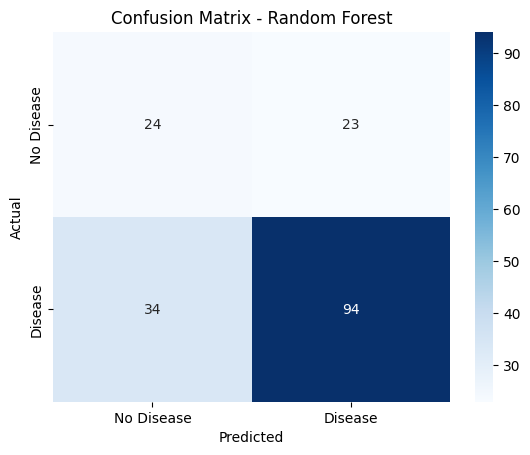


 Evaluation on Test Set: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.83      0.56        47
           1       0.90      0.59      0.71       128

    accuracy                           0.65       175
   macro avg       0.66      0.71      0.64       175
weighted avg       0.77      0.65      0.67       175



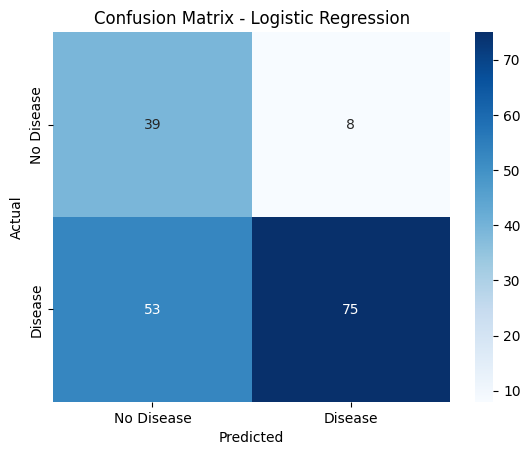


 Evaluation on Test Set: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.72      0.49        47
           1       0.84      0.55      0.66       128

    accuracy                           0.59       175
   macro avg       0.61      0.64      0.58       175
weighted avg       0.72      0.59      0.62       175



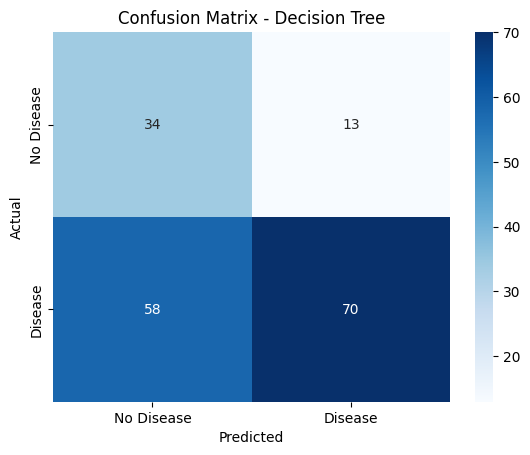

In [24]:
# Evaluate all on test set
results = []

for name, grid in best_models.items():
    print(f"\n Evaluation on Test Set: {name}")

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    f1 = grid.best_score_
    acc = accuracy_score(y_test, y_pred)

    results.append({'Model': name, 'CV_F1': f1, 'Test_Accuracy': acc})
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

""Getting very poor results even after hyperparameter tuning , Lets  make a combined strong model using stacking classifier""

### Stacking Model Classifier

In [25]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [26]:
base_learners = [
    ('svm', SVC(probability=True, kernel='rbf')),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('rf', RandomForestClassifier())
]

meta_learner = LogisticRegression()


In [27]:
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=True,
    cv=5,
    n_jobs=-1
)


In [28]:
stacking_pipeline = ImbPipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', stacking_model)
])

In [29]:
stacking_pipeline.fit(X_train, y_train)
y_pred = stacking_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.45      0.51      0.48        47
           1       0.81      0.77      0.79       128

    accuracy                           0.70       175
   macro avg       0.63      0.64      0.64       175
weighted avg       0.72      0.70      0.71       175



In [30]:
accuracy_score(y_pred,y_test)

0.7028571428571428

### HyperParameter Tuning of Stacking Model classifier

In [31]:

svm = SVC(probability=True, random_state=42)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

stacking_clf = StackingClassifier(
    estimators=[
        ('svm', svm),
        ('rf', rf),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True
)


stacking_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', stacking_clf)
])


param_grid = {
    'classifier__svm__C': [0.1, 1],
    'classifier__svm__kernel': ['linear', 'rbf'],

    'classifier__rf__n_estimators': [75,100,150],
    'classifier__rf__max_depth': [None, 10],

    'classifier__xgb__n_estimators': [50,75,100],
    'classifier__xgb__max_depth': [3, 4,5],

    'classifier__final_estimator__C': [0.1, 1.0],
}


random_search = RandomizedSearchCV(
    estimator=stacking_pipeline,
    param_distributions=param_grid,
    n_iter=50,  
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
y_pred = random_search.predict(X_test)

print(f"\n Best Params: {random_search.best_params_}")
print(f" Best CV Accuracy: {random_search.best_score_:.3f}")

from sklearn.metrics import classification_report
print("\n Test Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\Ankit\Desktop\MediSense\venv\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
85 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Ankit\Desktop\MediSense\venv\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Ankit\Desktop\MediSense\venv\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Ankit\Desktop\MediSense\venv\lib\site-packages\imblearn\pipeline.py", line 526, in fit
    self._final_estimator.


 Best Params: {'classifier__xgb__n_estimators': 75, 'classifier__xgb__max_depth': 3, 'classifier__svm__kernel': 'rbf', 'classifier__svm__C': 1, 'classifier__rf__n_estimators': 150, 'classifier__rf__max_depth': 10, 'classifier__final_estimator__C': 1.0}
 Best CV Accuracy: 0.689

 Test Classification Report:
              precision    recall  f1-score   support

  No Disease       0.49      0.60      0.54        47
     Disease       0.84      0.77      0.80       128

    accuracy                           0.73       175
   macro avg       0.67      0.68      0.67       175
weighted avg       0.75      0.73      0.73       175



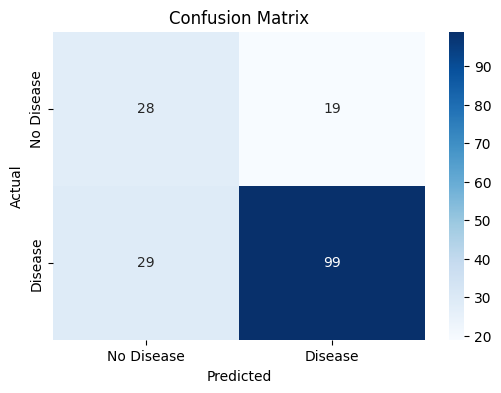

In [32]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

"The confusion matrix and classification metrics indicate the presence of class imbalance, as the model shows significantly higher performance on the majority class compared to the minority class, highlighting the challenges in achieving balanced predictive accuracy."

### Exporting the Model

In [33]:
import pickle

with open('LiverDiseaseModel.pkl', 'wb') as f:
    pickle.dump(random_search.best_estimator_, f)